In [10]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from tqdm import tqdm

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

from skimage.feature import graycomatrix, graycoprops

In [11]:
train_df = pd.read_csv('features/64/train_features.csv')
valid_df = pd.read_csv('features/64/valid_features.csv')

In [12]:
X_train = train_df.drop(columns=["filename", "label"])
y_train = train_df["label"]

X_test = valid_df.drop(columns=["filename", "label"])
y_test = valid_df["label"]

In [13]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [14]:

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [15]:
# Prediksi data train
y_train_pred = knn.predict(X_train_scaled)

# Prediksi data test
y_test_pred = knn.predict(X_test_scaled)

# Accuracy
train_acc = accuracy_score(y_train, y_train_pred)

test_acc = accuracy_score(y_test, y_test_pred)

print("Training Accuracy :", train_acc)
print("Testing Accuracy  :", test_acc)
print("\nClassification Report:\n")
print(classification_report(y_test, y_test_pred))

Training Accuracy : 0.9334696659850034
Testing Accuracy  : 0.8991780821917809

Classification Report:

                                          precision    recall  f1-score   support

              Grape Esca (Black_Measles)       0.85      0.85      0.85       480
Grape Leaf blight (Isariopsis_Leaf_Spot)       0.95      0.97      0.96       430
                      grape leaf Healthy       0.98      0.98      0.98       435
                    grape leaf black rot       0.83      0.81      0.82       480

                                accuracy                           0.90      1825
                               macro avg       0.90      0.90      0.90      1825
                            weighted avg       0.90      0.90      0.90      1825



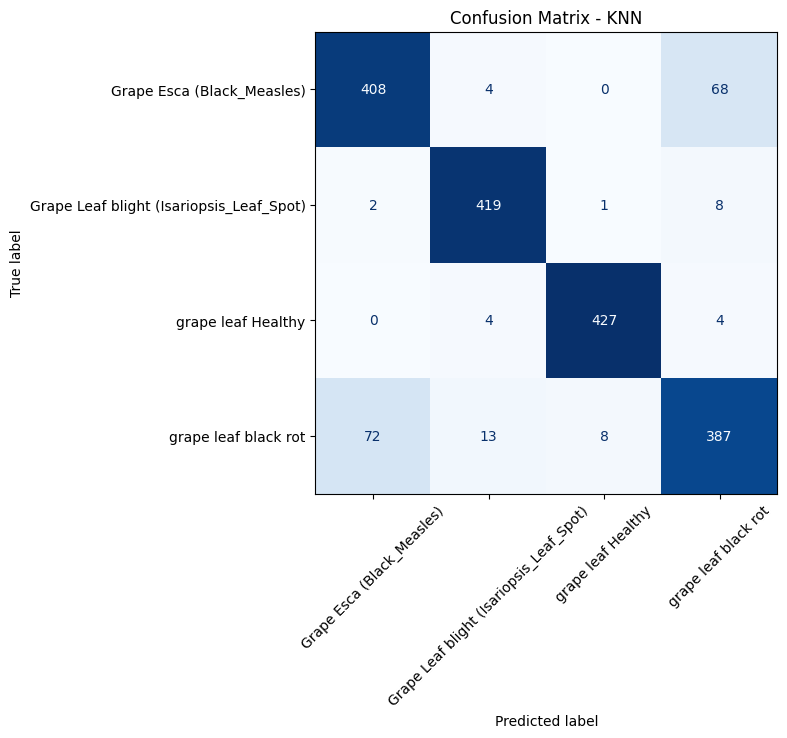

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=knn.classes_
)

fig, ax = plt.subplots(figsize=(8,6))
disp.plot(
    cmap="Blues",
    xticks_rotation=45,
    ax=ax,
    colorbar=False
)

plt.title("Confusion Matrix - KNN")
plt.show()

In [17]:
le = LabelEncoder()

y_train_ann = le.fit_transform(train_df["label"])
y_test_ann = le.transform(valid_df["label"])

print(le.classes_)

print("Contoh y encoded:", y_train_ann[:5])

['Grape Esca (Black_Measles)' 'Grape Leaf blight (Isariopsis_Leaf_Spot)'
 'grape leaf Healthy' 'grape leaf black rot']
Contoh y encoded: [0 0 0 0 0]


In [18]:
ann = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation="relu",
    solver="adam",
    alpha=0.0001,
    batch_size="auto",
    learning_rate_init=0.001,
    max_iter=300,
    random_state=42,
    early_stopping=True,
    n_iter_no_change=20,
    verbose=True
)

ann.fit(X_train_scaled, y_train_ann)

Iteration 1, loss = 0.63963285
Validation score: 0.852861
Iteration 2, loss = 0.31430915
Validation score: 0.895095
Iteration 3, loss = 0.23849465
Validation score: 0.912807
Iteration 4, loss = 0.19720380
Validation score: 0.925068
Iteration 5, loss = 0.16651632
Validation score: 0.926431
Iteration 6, loss = 0.17863963
Validation score: 0.916894
Iteration 7, loss = 0.13788402
Validation score: 0.933243
Iteration 8, loss = 0.12260569
Validation score: 0.935967
Iteration 9, loss = 0.11060141
Validation score: 0.927793
Iteration 10, loss = 0.21083311
Validation score: 0.925068
Iteration 11, loss = 0.12084625
Validation score: 0.934605
Iteration 12, loss = 0.10850632
Validation score: 0.942779
Iteration 13, loss = 0.09544639
Validation score: 0.949591
Iteration 14, loss = 0.08594091
Validation score: 0.946866
Iteration 15, loss = 0.08053601
Validation score: 0.948229
Iteration 16, loss = 0.07455597
Validation score: 0.950954
Iteration 17, loss = 0.06906738
Validation score: 0.953678
Iterat

MLPClassifier(early_stopping=True, hidden_layer_sizes=(128, 64), max_iter=300,
              n_iter_no_change=20, random_state=42, verbose=True)

In [19]:
y_train_pred_ann = ann.predict(X_train_scaled)
y_test_pred_ann = ann.predict(X_test_scaled)

train_acc_ann = accuracy_score(
    y_train_ann,
    y_train_pred_ann
)

test_acc_ann = accuracy_score(
    y_test_ann,
    y_test_pred_ann
)

print("Training Accuracy:", train_acc_ann)
print("Testing Accuracy :", test_acc_ann)

print("\nClassification Report:\n")
print(classification_report(y_test_ann, y_test_pred_ann, target_names=le.classes_))

Training Accuracy: 0.9950920245398773
Testing Accuracy : 0.9556164383561644

Classification Report:

                                          precision    recall  f1-score   support

              Grape Esca (Black_Measles)       0.93      0.94      0.94       480
Grape Leaf blight (Isariopsis_Leaf_Spot)       0.99      0.99      0.99       430
                      grape leaf Healthy       0.98      1.00      0.99       435
                    grape leaf black rot       0.93      0.91      0.92       480

                                accuracy                           0.96      1825
                               macro avg       0.96      0.96      0.96      1825
                            weighted avg       0.96      0.96      0.96      1825



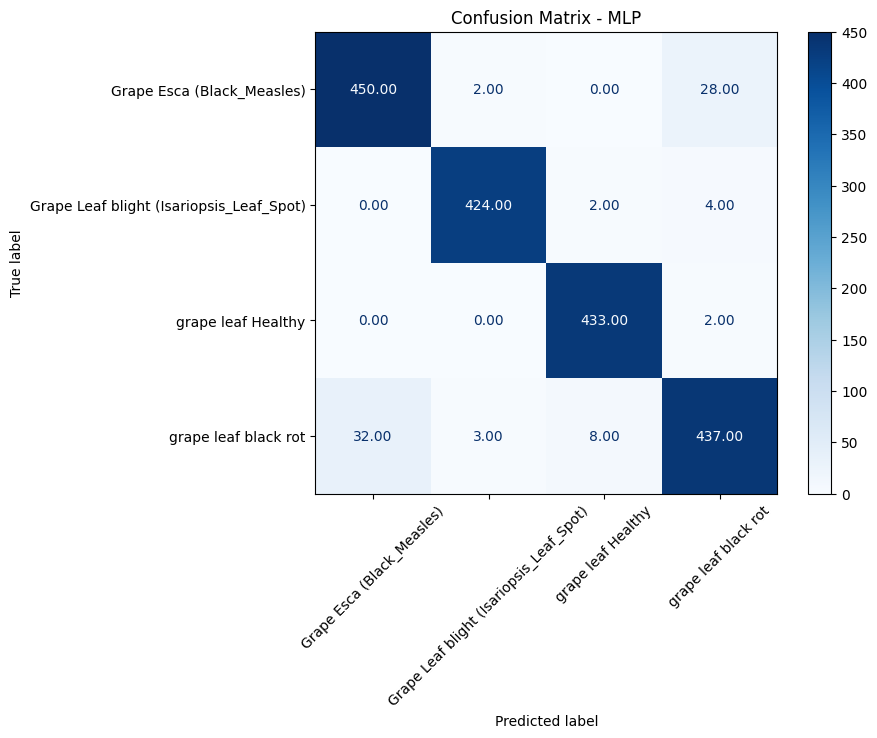

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_norm = confusion_matrix(
    y_test_ann,
    y_test_pred_ann
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_norm,
    display_labels=le.classes_
)

fig, ax = plt.subplots(figsize=(8,6))

disp.plot(
    cmap="Blues",
    values_format=".2f",
    xticks_rotation=45,
    ax=ax,
    colorbar=True
)

plt.title("Confusion Matrix - MLP")
plt.show()